# Лабораторная работа № 6

# Кластеризация

## Сегментация клиентов

Датасет — `Cust_Segmentation.csv`.

**Цель работы:** научиться производить кластерный анализ данных с использованием метода К-средних.

Набор данных содержит сведения о клиентах. Сегментация клиентов – это практика разбиения клиентской базы на группы людей со схожими характеристиками. Это важная стратегия, поскольку бизнес может нацеливаться на эти конкретные группы клиентов и эффективно распределять маркетинговые ресурсы. Например, одна группа может содержать клиентов с высокой прибылью и низким риском, то есть с большей вероятностью приобретающих продукты или подписывающихся на услуги. Задача бизнеса – удержать этих клиентов. Другая группа может включать клиентов из некоммерческих организаций.

Признаки:
- **Customer Id** — идентификатор клиента;
- **Age** — возраст;
- **Edu** — образование;
- **Years Employed** — сроки работы;
- **Income** — доход;
- **Card Debt** — долг по карте;
- **Other Debt** — другой долг;
- **Defaulted** — дефолт;
- **Address** — адрес;
- **DebtIncomeRatio** — соотношение долга и дохода.

# 0 шаг. Импортируем библиотеки

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1 шаг. Загружаем датасет в объект DataFrame

In [2]:
df = pd.read_csv('Cust_Segmentation.csv')
df.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2


In [3]:
print("Количество строк и столбцов:", df.shape)

Количество строк и столбцов: (850, 10)


> Датасет успешно загружен. В наборе данных содержатся сведения о клиентах: возраст, образование, стаж работы, доход, долги, информация о дефолте, адрес и отношение долга к доходу. Для задачи кластеризации целевая переменная не используется, так как необходимо самостоятельно разделить клиентов на группы по схожести признаков.

# 2 шаг. Получим представление о наборе данных

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer Id      850 non-null    int64  
 1   Age              850 non-null    int64  
 2   Edu              850 non-null    int64  
 3   Years Employed   850 non-null    int64  
 4   Income           850 non-null    int64  
 5   Card Debt        850 non-null    float64
 6   Other Debt       850 non-null    float64
 7   Defaulted        700 non-null    float64
 8   Address          850 non-null    object 
 9   DebtIncomeRatio  850 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 66.5+ KB


> По результатам `info()` видно, что в датасете присутствуют как числовые признаки, так и один текстовый признак `Address`. Большинство столбцов имеют числовой тип данных, поэтому подходят для дальнейшей кластеризации после обработки пропусков и масштабирования.


In [5]:
df.describe()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
count,850.00000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,700.000000,850.000000
mean,425.50000,35.029412,1.710588,8.565882,46.675294,1.576820,3.078773,0.261429,10.171647
std,245.51816,8.041432,0.927784,6.777884,38.543054,2.125843,3.398799,0.439727,6.719441
min,1.00000,20.000000,1.000000,0.000000,13.000000,0.012000,0.046000,0.000000,0.100000
25%,213.25000,29.000000,1.000000,3.000000,24.000000,0.382500,1.045750,0.000000,5.100000
50%,425.50000,34.000000,1.000000,7.000000,35.000000,0.885000,2.003000,0.000000,8.700000
75%,637.75000,41.000000,2.000000,13.000000,55.750000,1.898500,3.903250,1.000000,13.800000
max,850.00000,56.000000,5.000000,33.000000,446.000000,20.561000,35.197000,1.000000,41.300000


> Метод `describe()` показывает, что признаки имеют разные масштабы: например, возраст измеряется десятками лет, доход может принимать значительно большие значения, а долги представлены дробными числами. Для метода K-средних это важно, так как алгоритм основан на расстояниях между объектами. Поэтому перед обучением модели данные необходимо привести к единому масштабу с помощью стандартизации.

# 3 шаг. Произведем разведочный анализ данных

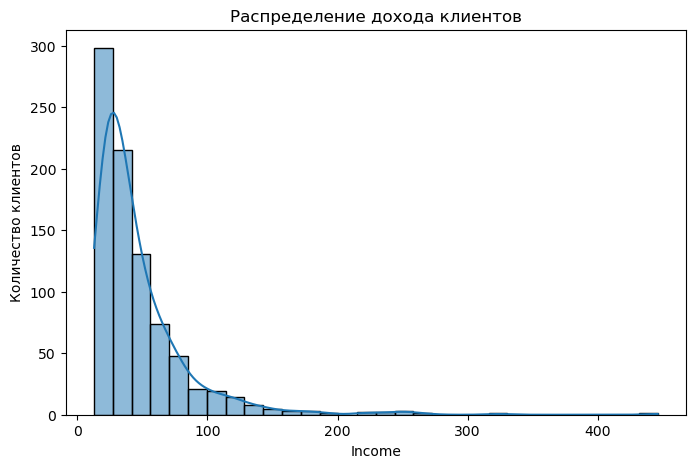

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Income'], bins=30, kde=True, color='C0')
plt.title('Распределение дохода клиентов')
plt.xlabel('Income')
plt.ylabel('Количество клиентов')
plt.show()

> График распределения дохода показывает, что большинство клиентов имеет сравнительно невысокий или средний доход. Очень большие значения `Income` встречаются заметно реже, поэтому распределение имеет правый хвост. Для кластеризации этот признак важен, так как уровень дохода может помогать выделять отдельные группы клиентов с разными финансовыми характеристиками.

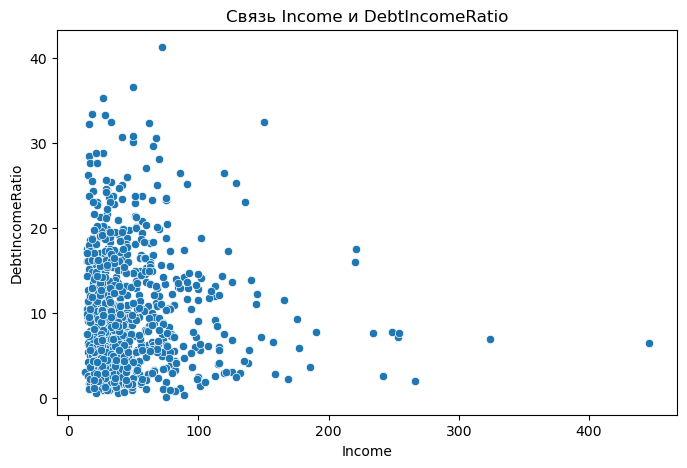

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Income', y='DebtIncomeRatio', data=df)
plt.title('Связь Income и DebtIncomeRatio')
plt.xlabel('Income')
plt.ylabel('DebtIncomeRatio')
plt.show()

> На диаграмме рассеяния показана связь между доходом клиента и отношением долга к доходу. Видно, что клиенты различаются не только по абсолютному уровню дохода, но и по долговой нагрузке. Для сегментации это важно: два клиента с похожим доходом могут относиться к разным группам, если у одного долговая нагрузка низкая, а у другого высокая. Поэтому признаки `Income` и `DebtIncomeRatio` могут быть полезны при выделении кластеров клиентов.

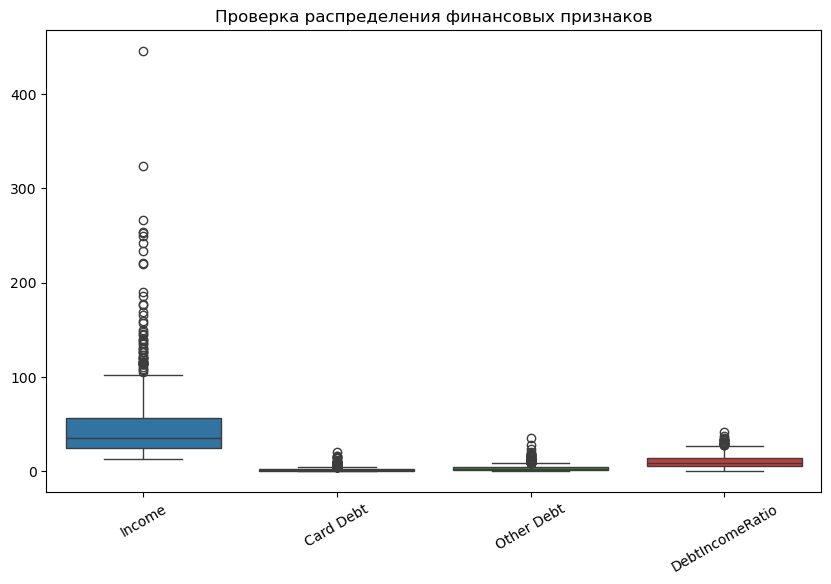

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['Income', 'Card Debt', 'Other Debt', 'DebtIncomeRatio']])
plt.title('Проверка распределения финансовых признаков')
plt.xticks(rotation=30)
plt.show()

> Boxplot показывает, что у финансовых признаков есть отдельные крупные значения. Особенно заметны большие значения у признака `Income`, а также отдельные повышенные значения у `Card Debt`, `Other Debt` и `DebtIncomeRatio`. В данной работе эти значения не удаляются автоматически, потому что для задачи сегментации они могут быть содержательно важными. Клиенты с высоким доходом, большим долгом или высокой долговой нагрузкой могут образовывать отдельные группы, которые модель должна выделить при кластеризации.

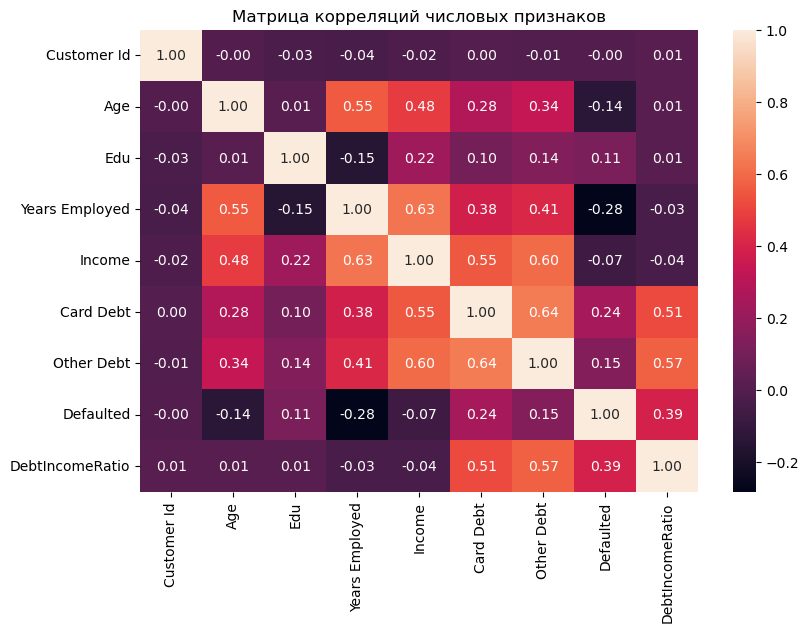

In [9]:
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f')
plt.title('Матрица корреляций числовых признаков')
plt.show()

> Наиболее заметная положительная связь наблюдается между `Card Debt` и `Other Debt`, а также между `Income` и долговыми признаками. Это логично, потому что клиенты с большим доходом могут иметь более высокие абсолютные значения долгов. Также видно, что `DebtIncomeRatio` связан с долговыми признаками, так как отражает отношение долга к доходу. Признак `Customer Id` не имеет содержательной связи с остальными признаками и далее не будет использоваться при обучении модели.

# 4 шаг. Проверяем данные на наличие пропущенных значений и выбросов

In [10]:
# проверяем на пропущенные значения
print(df.isnull().sum())

Customer Id          0
Age                  0
Edu                  0
Years Employed       0
Income               0
Card Debt            0
Other Debt           0
Defaulted          150
Address              0
DebtIncomeRatio      0
dtype: int64


> По результату проверки видно, что пропущенные значения присутствуют только в столбце `Defaulted`. Этот признак показывает наличие дефолта и принимает дискретные значения `0` и `1`. Поэтому пропуски в этом столбце будем заполнять наиболее часто встречающимся значением, то есть модой.

In [11]:
df_copy = df.copy()

# заполняем пропуски в столбце Defaulted модой
mode_defaulted = df_copy['Defaulted'].mode()[0]
df_copy['Defaulted'] = df_copy['Defaulted'].fillna(mode_defaulted)

# убедимся, что пропусков не осталось
print(df_copy.isnull().sum())

Customer Id        0
Age                0
Edu                0
Years Employed     0
Income             0
Card Debt          0
Other Debt         0
Defaulted          0
Address            0
DebtIncomeRatio    0
dtype: int64


> После заполнения пропусков повторная проверка показывает, что пропущенных значений в датасете не осталось. Теперь данные можно использовать для дальнейшей предобработки. Отдельные крупные значения в финансовых признаках не удаляются, так как в задаче сегментации они могут отражать реальные группы клиентов, а не ошибки в данных.

# 5 шаг. Произведем предобработку данных

Для кластеризации нужно оставить только признаки, которые содержательно описывают клиента. Признак `Customer Id` является идентификатором и не несет информации о поведении клиента. Признак `Address` является категориальным кодом адреса, если закодировать его числами, модель может ошибочно воспринять эти коды как расстояния между клиентами. Поэтому эти признаки отделяются от рабочего набора данных.

In [12]:
# сохраним идентификаторы клиентов отдельно, чтобы потом вернуть их к результатам кластеризации
customer_info = df_copy[['Customer Id', 'Address']]

# исключаем признаки, которые не должны участвовать в вычислении расстояний KMeans
y = df_copy[['Customer Id', 'Address']]
df_work = df_copy.drop(['Customer Id', 'Address'], axis=1)

df_work.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,41,2,6,19,0.124,1.073,0.0,6.3
1,47,1,26,100,4.582,8.218,0.0,12.8
2,33,2,10,57,6.111,5.802,1.0,20.9
3,29,2,4,19,0.681,0.516,0.0,6.3
4,47,1,31,253,9.308,8.908,0.0,7.2


> В рабочем наборе данных остались только признаки, которые можно использовать для расчета расстояний между клиентами: возраст, образование, стаж работы, доход, долги, дефолт и отношение долга к доходу. Признак `Defaulted` уже представлен в числовом дискретном виде `0/1`, поэтому дополнительное кодирование через `LabelEncoder` для него не требуется. Признак `Address` не кодируется, потому что его числовое представление могло бы внести искусственный порядок между адресами.

## Применяем операцию нормализации для численной устойчивости

Метод K-средних чувствителен к масштабу признаков, так как использует расстояния между объектами. Если не выполнить стандартизацию, признаки с большими числовыми значениями, например `Income`, будут сильнее влиять на результат, чем признаки с меньшим масштабом, например `Card Debt` или `Other Debt`.

In [13]:
# импортируем класс для стандартизации данных
from sklearn.preprocessing import StandardScaler

# создадим объект класса StandardScaler
scaler = StandardScaler()
scaler

,copy,True
,with_mean,True
,with_std,True


## Приведем данные к единому масштабу

In [14]:
X = scaler.fit_transform(df_work)

# посмотрим на первые 4 строки стандартизированных данных
print(X[:4])

[[ 0.74291541  0.31212243 -0.37878978 -0.71845859 -0.68381116 -0.59048916
  -0.52379654 -0.57652509]
 [ 1.48949049 -0.76634938  2.5737211   1.38432469  1.41447366  1.51296181
  -0.52379654  0.39138677]
 [-0.25251804  0.31212243  0.2117124   0.26803233  2.13414111  0.80170393
   1.90913822  1.59755385]
 [-0.75023477  0.31212243 -0.67404087 -0.71845859 -0.42164323 -0.75446707
  -0.52379654 -0.57652509]]


> После стандартизации значения признаков изменились: теперь они выражены не в исходных единицах измерения, а в стандартизированном виде. Это нормальный этап подготовки данных для KMeans. При этом исходные значения признаков сохраняются в датафрейме `df_work`, поэтому позже их можно будет использовать для интерпретации кластеров.

## Определяем оптимальное количество кластеров с помощью метода локтя

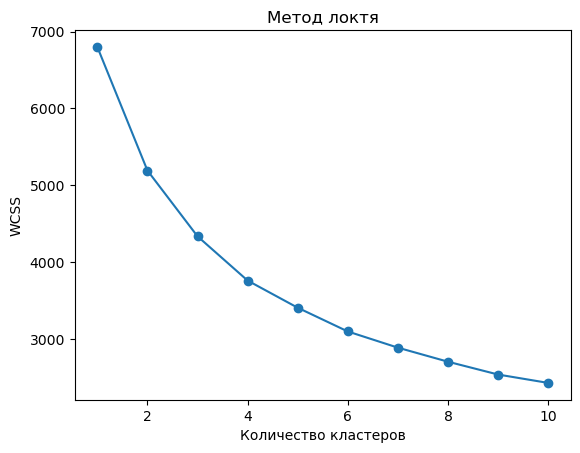

In [15]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Метод локтя')
plt.xlabel('Количество кластеров')
plt.ylabel('WCSS')
plt.show()

> На графике метода локтя значение WCSS быстро уменьшается при переходе от одного к нескольким кластерам, а затем снижение становится более плавным. Для данного датасета разумно выбрать `3` кластера: такое количество позволяет разделить клиентов на несколько интерпретируемых сегментов и при этом не усложняет модель слишком сильно.

# 6 шаг. Произведем обучение модели методом K-средних

In [16]:
# создаем экземпляр модели
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)

# обучаем модель на стандартизированных данных
kmeans.fit(X)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


> Модель кластеризации обучена на подготовленных признаках. На этом этапе алгоритм определил центры кластеров в стандартизированном пространстве признаков и распределил клиентов по группам так, чтобы клиенты внутри одного кластера были похожи друг на друга.

## Предсказываем кластеры и добавляем результат в таблицу

In [17]:
# предсказываем кластеры для каждого наблюдения
clusters = kmeans.predict(X)

# добавляем метки кластеров в рабочие данные
df_clustered = df_work.copy()
df_clustered['cluster'] = clusters

df_clustered.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio,cluster
0,41,2,6,19,0.124,1.073,0.0,6.3,2
1,47,1,26,100,4.582,8.218,0.0,12.8,0
2,33,2,10,57,6.111,5.802,1.0,20.9,1
3,29,2,4,19,0.681,0.516,0.0,6.3,2
4,47,1,31,253,9.308,8.908,0.0,7.2,0


> В таблице появился новый столбец `cluster`, который показывает, к какому кластеру модель отнесла каждого клиента. Номера кластеров являются условными: кластер `0` не обязательно лучше или хуже кластера `1`. Смысл каждого кластера определяется только после анализа средних значений признаков внутри групп.

## Подготовим координаты центроидов для визуализации

Центроид — это центр кластера. Так как модель обучалась на стандартизированных данных, сначала центроиды находятся в стандартизированном масштабе. Для построения графиков по реальным признакам переведем координаты центроидов обратно в исходный масштаб.

In [18]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=df_work.columns)
centroids_df

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,43.000000,1.931973,17.197279,101.959184,4.220673,7.954483,1.292517e-01,13.915646
1,31.891566,1.861446,3.963855,31.789157,1.576675,2.843355,9.879518e-01,13.994578
2,33.817505,1.603352,7.625698,36.143389,0.853128,1.816855,3.053113e-16,7.964991


> Таблица центроидов показывает усреднённый портрет каждого кластера в исходных признаках. Кластер 0 отличается более высоким средним возрастом, большим стажем работы, самым высоким доходом и более крупными значениями долгов. Кластер 1 имеет более низкий доход и высокий средний показатель `Defaulted`, поэтому в нём могут находиться клиенты с более выраженным риском дефолта. Кластер 2 характеризуется сравнительно невысокими долгами и меньшим значением `DebtIncomeRatio`, что может соответствовать клиентам с более устойчивым финансовым положением.

## 7 шаг. Визуализируем кластеры в координатах реальных признаков

Построим графики кластеров до применения PCA. Это нужно для того, чтобы увидеть группы клиентов в системе координат реальных признаков, а не только после снижения размерности. В качестве признаков возьмем финансовые характеристики, которые хорошо подходят для интерпретации сегментов клиентов.

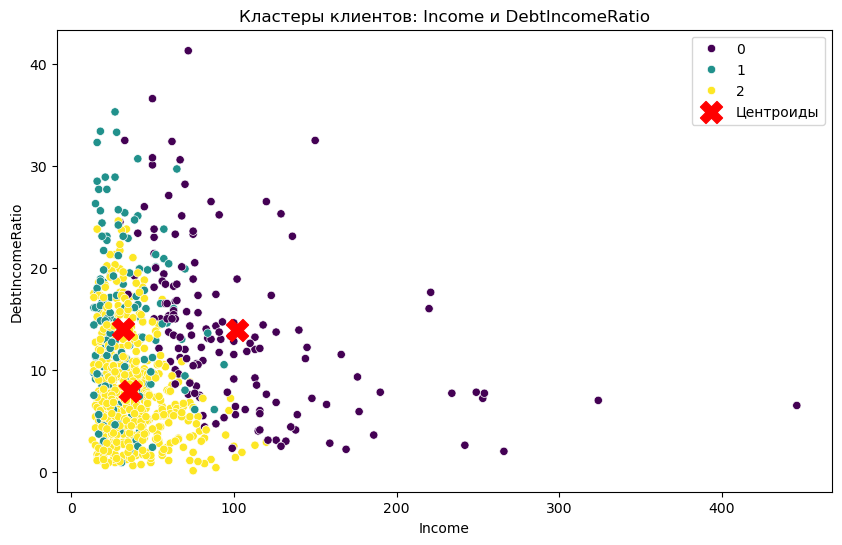

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clustered, x='Income', y='DebtIncomeRatio', hue='cluster', palette='viridis')
plt.scatter(centroids_df['Income'], centroids_df['DebtIncomeRatio'], s=250, c='red', marker='X', label='Центроиды')
plt.title('Кластеры клиентов: Income и DebtIncomeRatio')
plt.xlabel('Income')
plt.ylabel('DebtIncomeRatio')
plt.legend()
plt.show()

> На графике показано распределение клиентов по доходу и отношению долга к доходу. Центроиды отмечают условные центры найденных кластеров. Такой график помогает увидеть, какие группы клиентов отличаются по уровню дохода и долговой нагрузке. Клиенты с близкими финансовыми характеристиками попадают в одни и те же области графика, а значит, модель действительно выделяет сегменты по экономическому поведению.

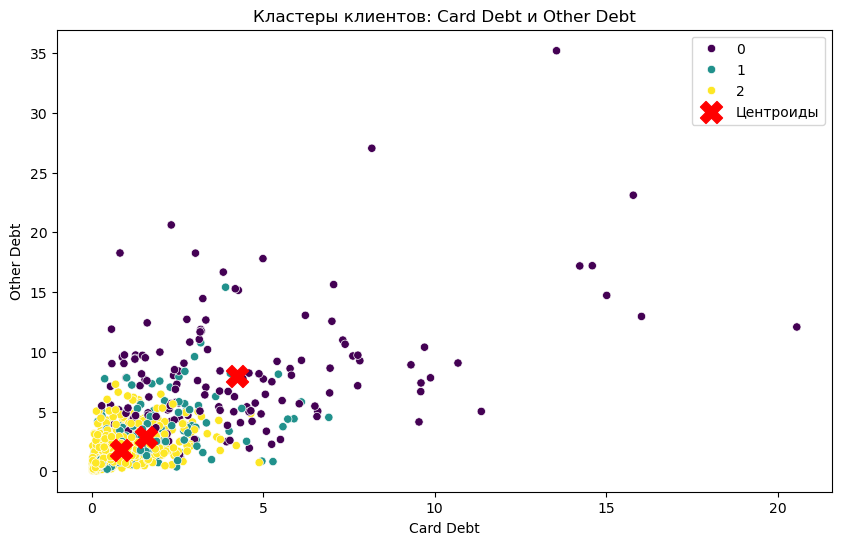

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clustered, x='Card Debt', y='Other Debt', hue='cluster', palette='viridis')
plt.scatter(centroids_df['Card Debt'], centroids_df['Other Debt'], s=250, c='red', marker='X', label='Центроиды')
plt.title('Кластеры клиентов: Card Debt и Other Debt')
plt.xlabel('Card Debt')
plt.ylabel('Other Debt')
plt.legend()
plt.show()

> Второй график показывает кластеры в координатах долговых признаков. Он позволяет оценить, как клиенты распределяются по долгу по карте и другим долгам. Наличие центроидов на графике помогает понять среднее положение каждого сегмента: одни группы клиентов имеют низкие долги, другие - более выраженную долговую нагрузку.

## 8 шаг. Произведем снижение размерности данных с помощью метода PCA

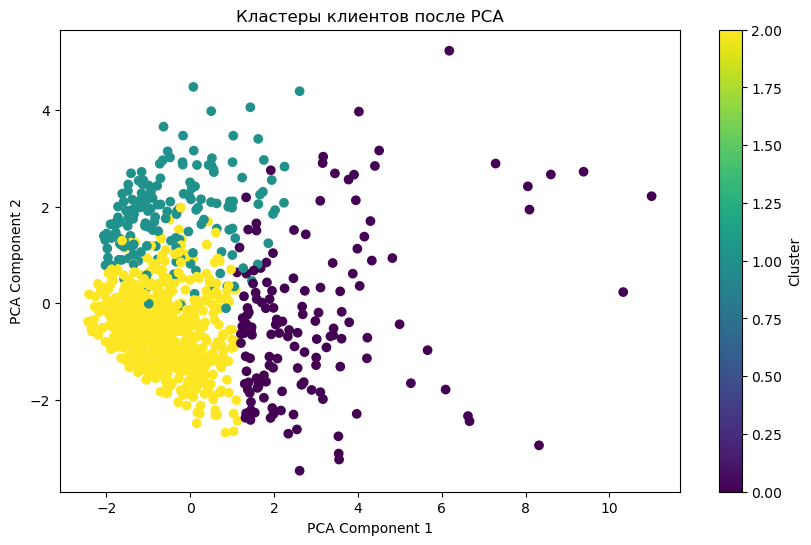

In [21]:
from sklearn.decomposition import PCA

# уменьшаем размерность до 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# визуализация
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Кластеры клиентов после PCA')
plt.colorbar(scatter, label='Cluster')
plt.show()

> График PCA показывает расположение клиентов после преобразования исходных признаков в две главные компоненты. Цветом обозначена принадлежность клиента к кластеру. Видно, что часть кластеров отделяется достаточно заметно, однако полного разделения нет: некоторые клиенты находятся на границах между сегментами. Это нормально для клиентских данных, так как реальные группы клиентов часто имеют плавные переходы, а не жёсткие границы.

## 9 шаг. Проведем разведочный анализ данных по кластерам

In [23]:
# возвращаем идентификаторы и адреса клиентов к результатам кластеризации
df_result = df_clustered.copy()
df_result['Customer Id'] = customer_info['Customer Id']
df_result['Address'] = customer_info['Address']

cols = ['Customer Id', 'Address'] + list(df_work.columns) + ['cluster']
df_result = df_result[cols]

df_result.head()

,Customer Id,Address,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio,cluster
0,1,NBA001,41,2,6,19,0.124,1.073,0.0,6.3,2
1,2,NBA021,47,1,26,100,4.582,8.218,0.0,12.8,0
2,3,NBA013,33,2,10,57,6.111,5.802,1.0,20.9,1
3,4,NBA009,29,2,4,19,0.681,0.516,0.0,6.3,2
4,5,NBA008,47,1,31,253,9.308,8.908,0.0,7.2,0


In [24]:
# группируем по кластерам и анализируем средние значения
cluster_groups = df_result.groupby('cluster')
cluster_summary = cluster_groups[df_work.columns].mean()
cluster_summary

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
cluster,,,,,,,,
0,43.000000,1.931973,17.197279,101.959184,4.220673,7.954483,0.129252,13.915646
1,31.891566,1.861446,3.963855,31.789157,1.576675,2.843355,0.987952,13.994578
2,33.817505,1.603352,7.625698,36.143389,0.853128,1.816855,0.000000,7.964991


In [25]:
# количество клиентов в каждом кластере
df_result['cluster'].value_counts().sort_index()

cluster
0    147
1    166
2    537
Name: count, dtype: int64

> Средние значения признаков показывают различия между найденными группами клиентов. По ним можно оценить, какие кластеры характеризуются более высоким доходом, большим стажем работы, высокой долговой нагрузкой или наличием дефолта. Количество клиентов в каждом кластере показывает размер сегмента и помогает понять, является ли группа массовой или более узкой.

## 10 шаг. Интерпретация результатов

In [26]:
print("\nСостав кластеров")
for cluster_num in sorted(df_result['cluster'].unique()):
    cluster_data = df_result[df_result['cluster'] == cluster_num]
    print(f"\nКластер {cluster_num}:")
    print(f"Количество клиентов: {len(cluster_data)}")
    print("Первые 15 Customer Id:", cluster_data['Customer Id'].head(15).values)


Состав кластеров

Кластер 0:
Количество клиентов: 147
Первые 15 Customer Id: [ 2  5  6 10 19 24 25 32 40 42 44 46 51 52 61]

Кластер 1:
Количество клиентов: 166
Первые 15 Customer Id: [ 3 11 15 23 33 37 38 41 53 55 56 57 68 70 82]

Кластер 2:
Количество клиентов: 537
Первые 15 Customer Id: [ 1  4  7  8  9 12 13 14 16 17 18 20 21 22 26]


**Интерпретация результатов:**

- **Кластер 0** — клиенты более старшего возраста с большим стажем работы, высоким средним доходом и более крупными значениями долгов. При этом среднее значение `Defaulted` у них невысокое, поэтому этот сегмент можно описать как клиентов с высоким доходом и существенными финансовыми обязательствами, но без массового дефолта.

- **Кластер 1** — клиенты с небольшим стажем работы, сравнительно невысоким доходом и высокой долей дефолта. Для этой группы характерна повышенная долговая нагрузка относительно дохода, поэтому данный сегмент можно считать более рискованным.

- **Кластер 2** — самая большая группа клиентов. У них умеренные значения возраста, дохода и долгов, а среднее значение `Defaulted` близко к нулю. Этот кластер можно интерпретировать как основной стабильный сегмент клиентов с относительно невысокой долговой нагрузкой.

В результате работы модель KMeans разделила клиентов на три группы, отличающиеся уровнем дохода, долговой нагрузкой, стажем работы и наличием дефолта. Такое разбиение может быть полезно для анализа клиентской базы и выбора разных стратегий взаимодействия с клиентами.